# 🌫️ 대기질 PM10 / PM25 예측 모델 (LSTM)

### 개요
- **목표**: 기상 데이터 + 오염물질 데이터 → PM10 / PM25 농도 예측
- **모델**: LSTM (Long Short-Term Memory) — 24시간 시퀀스 입력
- **데이터**: `air_quality_train.csv` (generate_dataset.py 로 생성)

### 노트북 흐름
```
1. GPU 확인 & 패키지 설치
2. 데이터 업로드 & 탐색
3. 전처리 & 시퀀스 생성
4. LSTM 모델 정의
5. 학습
6. 평가 & 시각화
7. 모델 다운로드
```

---
## 1. GPU 확인 & 패키지 설치

In [ ]:
# Colab 런타임 메뉴 → 런타임 유형 변경 → T4 GPU 선택 후 실행하세요
!nvidia-smi

In [9]:
# 필요한 패키지 설치 (Colab에는 torch, pandas, sklearn이 기본 설치되어 있음)
# tqdm만 확인용으로 설치
#!pip install tqdm --quiet

# 한글 폰트 설치 (matplotlib 차트 한글 깨짐 방지)
!apt-get install -y fonts-nanum > /dev/null 2>&1
print("패키지 & 한글 폰트 설치 완료")

패키지 & 한글 폰트 설치 완료


---
## 2. 라이브러리 임포트

In [10]:
import os
import json
import math
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm   # Colab용 tqdm (진행바가 셀 안에 표시됨)

# ── 한글 폰트 설정 (NanumGothic) ────────────────────────────
# fonts-nanum 설치 후 폰트를 matplotlib에 직접 등록
_NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(_NANUM_PATH):
    fm.fontManager.addfont(_NANUM_PATH)
    mpl.rcParams['font.family'] = 'NanumGothic'
else:
    # 로컬 실행 환경: 시스템에 설치된 한글 폰트 자동 탐색
    _candidates = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name or 'Malgun' in f.name]
    if _candidates:
        mpl.rcParams['font.family'] = _candidates[0]
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호 깨짐 방지
print(f"폰트 설정: {mpl.rcParams['font.family']}")

# ── 디바이스 설정 ──────────────────────────────────────────────
# Colab GPU 런타임이면 'cuda', CPU 런타임이면 'cpu'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU 이름    : {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  GPU가 없습니다. 런타임 유형 변경 → GPU 선택을 권장합니다.")

폰트 설정: ['NanumGothic']
사용 디바이스: cuda
GPU 이름    : Tesla T4
GPU 메모리   : 15.6 GB


---
## 3. 데이터 업로드

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread("air_quality_train.csv")

---
## 4. 데이터 탐색 (EDA)

In [11]:
# CSV 로드
df = pd.read_csv("air_quality_train.csv")

print(f"전체 행 수  : {len(df):,}")
print(f"컬럼 수    : {len(df.columns)}")
print(f"기간       : {df['date'].min()} ~ {df['date'].max()}")
print(f"지역 목록  : {df['district'].unique().tolist()}")
print()
df.head()

전체 행 수  : 87,720
컬럼 수    : 30
기간       : 2024-01-01 ~ 2025-12-31
지역 목록  : ['강남구', '종로구', '마포구', '강서구', '노원구']



,date,year,month,day,hour,day_of_week,season,district,lat,lon,...,o3,pm10,pm25,level,pm10_lag1,pm25_lag1,pm10_lag3,pm25_lag3,pm10_lag24,pm25_lag24
0,2024-01-01,2024,1,1,0,0,0,강남구,37.5172,127.0473,...,0.0093,39.7,16.6,yellow,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-01-01,2024,1,1,0,0,0,종로구,37.5735,126.9788,...,0.0101,37.1,23.9,yellow,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-01-01,2024,1,1,0,0,0,마포구,37.5663,126.9019,...,0.0095,35.7,19.9,yellow,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-01-01,2024,1,1,0,0,0,강서구,37.5509,126.8495,...,0.0097,43.7,22.7,yellow,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-01-01,2024,1,1,0,0,0,노원구,37.6542,127.0568,...,0.0138,30.5,15.7,yellow,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# PM10 / PM25 기초 통계
print("── PM10 / PM25 기초 통계 ──")
df[["pm10", "pm25"]].describe().round(2)

── PM10 / PM25 기초 통계 ──


,pm10,pm25
count,87720.00,87720.00
mean,30.74,17.69
std,20.44,12.03
min,5.00,2.00
25%,19.80,11.10
50%,26.90,15.50
75%,35.40,20.70
max,296.30,174.80


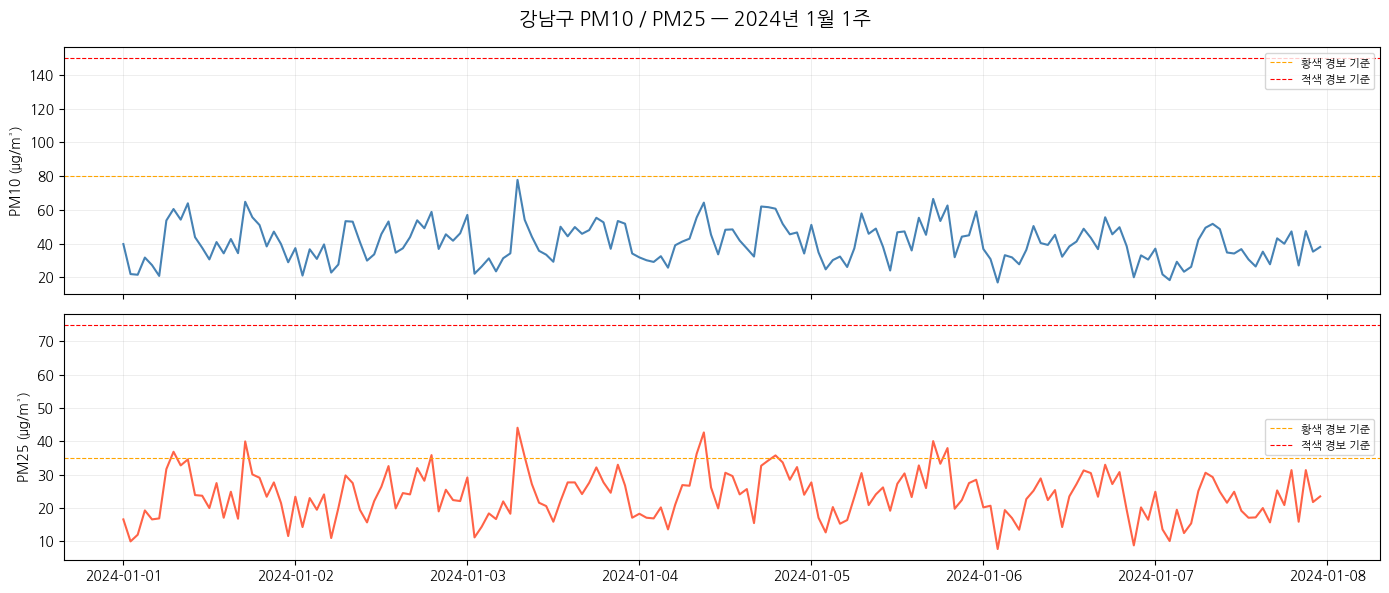

In [12]:
# 시각화: 강남구 PM10/PM25 7일 샘플
sample = df[(df["district"] == "강남구") & (df["date"] < "2024-01-08")].copy()
sample["datetime"] = pd.to_datetime(sample["date"]) + pd.to_timedelta(sample["hour"], unit="h")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle("강남구 PM10 / PM25 — 2024년 1월 1주", fontsize=14)

axes[0].plot(sample["datetime"], sample["pm10"], color="steelblue", linewidth=1.5)
axes[0].axhline(80, color="orange", linestyle="--", linewidth=0.8, label="황색 경보 기준")
axes[0].axhline(150, color="red", linestyle="--", linewidth=0.8, label="적색 경보 기준")
axes[0].set_ylabel("PM10 (μg/m³)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(sample["datetime"], sample["pm25"], color="tomato", linewidth=1.5)
axes[1].axhline(35, color="orange", linestyle="--", linewidth=0.8, label="황색 경보 기준")
axes[1].axhline(75, color="red", linestyle="--", linewidth=0.8, label="적색 경보 기준")
axes[1].set_ylabel("PM25 (μg/m³)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

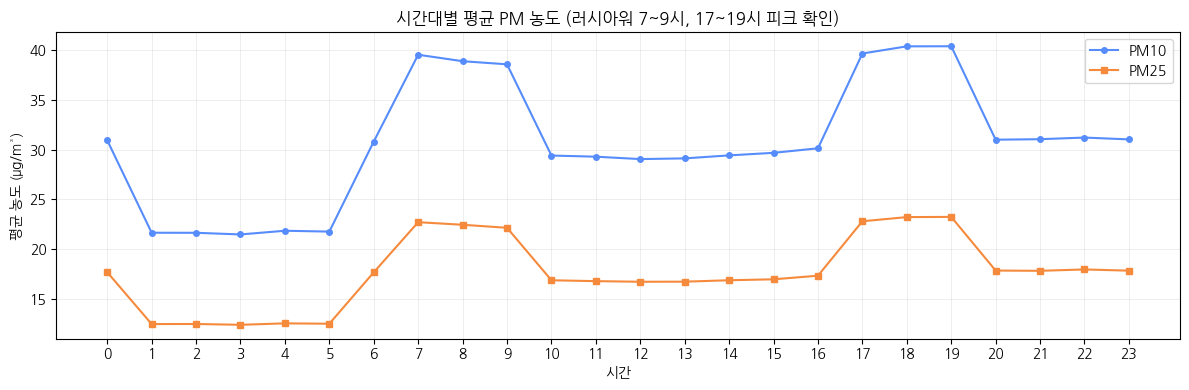

In [13]:
# 시각화: 시간대별 PM10 평균 (러시아워 패턴 확인)
hourly_mean = df.groupby("hour")[["pm10", "pm25"]].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_mean.index, hourly_mean["pm10"], label="PM10", marker="o", markersize=4)
ax.plot(hourly_mean.index, hourly_mean["pm25"], label="PM25", marker="s", markersize=4)
ax.set_xlabel("시간")
ax.set_ylabel("평균 농도 (μg/m³)")
ax.set_title("시간대별 평균 PM 농도 (러시아워 7~9시, 17~19시 피크 확인)")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. 하이퍼파라미터 설정

In [47]:
# ══════════════════════════════════════════════════════════════
#  학습에 사용할 설정값 — 필요에 따라 수정하세요
# ══════════════════════════════════════════════════════════════

CONFIG = {
    # 시퀀스 설정
    "seq_len"     : 24,     # 입력 윈도우 크기 (24시간 = 1일치 과거 데이터)

    # LSTM 구조
    "hidden_size" : 128,    # LSTM 히든 유닛 수 (클수록 표현력 ↑, 속도 ↓)
    "num_layers"  : 2,      # LSTM 레이어 수
    "dropout"     : 0.2,    # 드롭아웃 비율 (과적합 방지)

    # 학습 설정
    "epochs"      : 45,     # 전체 학습 반복 횟수
    "batch_size"  : 512,    # 배치 크기 (GPU 메모리에 맞게 조정)
    "lr"          : 1e-3,   # 초기 학습률
    "weight_decay": 1e-5,   # L2 정규화 (과적합 방지)

    # 데이터 분할 비율 (시간 순서 유지 — 미래 데이터 누수 방지)
    "train_ratio" : 0.70,   # 학습 70%
    "val_ratio"   : 0.85,   # 검증 15% (0.70 ~ 0.85)
    # 테스트는 나머지 15%

    # 저장 경로
    "save_dir"    : "model_output",
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
print("설정 확인:")
for k, v in CONFIG.items():
    print(f"  {k:<15}: {v}")

설정 확인:
  seq_len        : 24
  hidden_size    : 128
  num_layers     : 2
  dropout        : 0.2
  epochs         : 45
  batch_size     : 512
  lr             : 0.001
  weight_decay   : 1e-05
  train_ratio    : 0.7
  val_ratio      : 0.85
  save_dir       : model_output


---
## 6. 전처리 & 시퀀스 생성

In [40]:
# ── 입력 feature 목록 ──────────────────────────────────────────
# LSTM의 각 타임스텝에 입력되는 변수들
FEATURE_COLS = [
    # 시간 정보
    "hour",          # 시간 (0~23) — 러시아워 / 야간 패턴
    "month",         # 월 (1~12)   — 계절 패턴
    "day_of_week",   # 요일 (0=월요일, 6=일요일) — 주말 감소 효과
    "season",        # 계절 (0=겨울, 1=봄, 2=여름, 3=가을)

    # 기상 변수
    "temperature",   # 기온 (°C)
    "humidity",      # 상대습도 (%)
    "dew_point",     # 이슬점 (°C) — 실제 수분량
    "wind_speed",    # 풍속 (m/s) — 클수록 PM 분산
    "wind_direction",# 풍향 (도) — 중국 방향 바람 시 PM 유입
    "pressure",      # 기압 (hPa) — 고기압 시 PM 축적

    # 공동 오염물질 (PM과 발생원이 같아 상관관계 높음)
    "no2",           # 이산화질소 (ppm) — 교통량 지표
    "so2",           # 이산화황 (ppm)   — 화력발전, 난방
    "co",            # 일산화탄소 (ppm) — 불완전연소
    "o3",            # 오존 (ppm)       — 낮 시간 광화학 반응

    # 이전 시간 PM 값 (시퀀스 내에서 자연스럽게 제공됨)
    "pm10",          # PM10 (μg/m³) — 시퀀스 내 과거값
    "pm25",          # PM25 (μg/m³) — 시퀀스 내 과거값
]

# 예측 대상 (타겟)
TARGET_COLS = ["pm10", "pm25"]

print(f"입력 feature 수 : {len(FEATURE_COLS)}")
print(f"예측 대상       : {TARGET_COLS}")

입력 feature 수 : 16
예측 대상       : ['pm10', 'pm25']


In [30]:
# ── 시간 기반 데이터 분할 ──────────────────────────────────────
# 중요: 시계열 데이터는 반드시 날짜 순서로 분할해야 함
# (랜덤 분할 시 미래 정보가 학습에 누수되는 data leakage 발생)

dates = sorted(df["date"].unique())
n = len(dates)

train_end = dates[int(n * CONFIG["train_ratio"]) - 1]
val_end   = dates[int(n * CONFIG["val_ratio"])  - 1]

df_train = df[df["date"] <= train_end].copy()
df_val   = df[(df["date"] > train_end) & (df["date"] <= val_end)].copy()
df_test  = df[df["date"] > val_end].copy()

print(f"학습 데이터 : {df_train['date'].min()} ~ {df_train['date'].max()}  ({len(df_train):,}행)")
print(f"검증 데이터 : {df_val['date'].min()}   ~ {df_val['date'].max()}  ({len(df_val):,}행)")
print(f"테스트 데이터: {df_test['date'].min()}  ~ {df_test['date'].max()}  ({len(df_test):,}행)")

학습 데이터 : 2024-01-01 ~ 2025-05-25  (61,320행)
검증 데이터 : 2025-05-26   ~ 2025-09-12  (13,200행)
테스트 데이터: 2025-09-13  ~ 2025-12-31  (13,200행)


In [31]:
def build_sequences(df, seq_len, scaler=None, fit_scaler=False):
    """
    데이터프레임 → LSTM 입력 시퀀스 변환

    동작 방식:
      - 지역(district)별로 시간 순서 정렬
      - 슬라이딩 윈도우: [t-seq_len, ..., t-1] 입력 → [t] 예측
      - 지역 경계를 넘는 윈도우는 제외

    Args:
        df         : 입력 데이터프레임
        seq_len    : 입력 시퀀스 길이 (시간 수)
        scaler     : StandardScaler 객체 (None이면 새로 생성)
        fit_scaler : True면 scaler를 이 데이터로 학습 (훈련 데이터에만 True)

    Returns:
        X      : (샘플 수, seq_len, feature 수) — LSTM 입력
        y      : (샘플 수, 2)                  — [pm10, pm25] 정답
        scaler : 정규화에 사용된 scaler 객체
    """
    # 지역별, 날짜+시간 순서로 정렬 (지역 경계 처리를 위해 필수)
    df = df.sort_values(["district", "date", "hour"]).reset_index(drop=True)

    feature_data = df[FEATURE_COLS].values.astype(np.float32)
    target_data  = df[TARGET_COLS].values.astype(np.float32)
    district_arr = df["district"].values

    # 정규화: 훈련 데이터로만 scaler 학습, 나머지는 동일 scaler로 변환
    if fit_scaler:
        scaler = StandardScaler()
        feature_data = scaler.fit_transform(feature_data)
    else:
        feature_data = scaler.transform(feature_data)

    sequences, targets = [], []
    for i in range(seq_len, len(df)):
        # 윈도우 시작과 끝이 같은 지역인지 확인
        if district_arr[i - seq_len] != district_arr[i]:
            continue
        sequences.append(feature_data[i - seq_len : i])  # (seq_len, n_features)
        targets.append(target_data[i])                   # (pm10, pm25) at time i

    X = np.array(sequences, dtype=np.float32)
    y = np.array(targets,   dtype=np.float32)
    return X, y, scaler


# 시퀀스 생성
print("시퀀스 생성 중...")
SEQ_LEN = CONFIG["seq_len"]

# 훈련 데이터로 scaler 학습 (fit_scaler=True)
X_train, y_train, scaler = build_sequences(df_train, SEQ_LEN, fit_scaler=True)
# 검증/테스트는 훈련 scaler 재사용 (fit_scaler=False)
X_val,   y_val,   _      = build_sequences(df_val,   SEQ_LEN, scaler=scaler)
X_test,  y_test,  _      = build_sequences(df_test,  SEQ_LEN, scaler=scaler)

print(f"훈련  시퀀스: {X_train.shape}")
print(f"검증  시퀀스: {X_val.shape}")
print(f"테스트 시퀀스: {X_test.shape}")
print(f"\n각 시퀀스 shape: (seq_len={SEQ_LEN}, features={len(FEATURE_COLS)})")

# scaler 저장 (나중에 추론 시 동일한 정규화 적용을 위해)
with open(os.path.join(CONFIG["save_dir"], "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print("\nscaler 저장 완료")

시퀀스 생성 중...
훈련  시퀀스: (61200, 24, 16)
검증  시퀀스: (13080, 24, 16)
테스트 시퀀스: (13080, 24, 16)

각 시퀀스 shape: (seq_len=24, features=16)

scaler 저장 완료


In [32]:
# ── PyTorch Dataset & DataLoader ───────────────────────────────

class AirQualityDataset(Dataset):
    """PyTorch Dataset: numpy 배열 → Tensor 변환"""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH = CONFIG["batch_size"]

train_loader = DataLoader(
    AirQualityDataset(X_train, y_train),
    batch_size=BATCH,
    shuffle=True,       # 훈련: 매 epoch마다 순서를 섞어 편향 방지
    num_workers=2,      # 데이터 로딩 병렬화
    pin_memory=True,    # GPU 메모리 전송 속도 향상
)
val_loader = DataLoader(
    AirQualityDataset(X_val, y_val),
    batch_size=BATCH,
    shuffle=False,      # 검증/테스트: 순서 유지
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    AirQualityDataset(X_test, y_test),
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"DataLoader 생성 완료")
print(f"  훈련 배치 수 : {len(train_loader)}")
print(f"  검증 배치 수 : {len(val_loader)}")
print(f"  테스트 배치 수: {len(test_loader)}")

DataLoader 생성 완료
  훈련 배치 수 : 120
  검증 배치 수 : 26
  테스트 배치 수: 26


---
## 7. LSTM 모델 정의

In [41]:
class AirQualityLSTM(nn.Module):
    """
    대기질 예측 LSTM 모델

    구조:
        입력: (batch, seq_len, input_size)
          ↓
        LSTM × num_layers
          ↓
        마지막 타임스텝 hidden state
          ↓
        LayerNorm → Dropout → Linear(hidden → hidden//2) → ReLU
          ↓
        Linear(hidden//2 → 2) → ReLU  (PM 값은 항상 ≥ 0)
          ↓
        출력: (batch, 2)  = [pm10, pm25]
    """
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()

        # LSTM: 시계열의 장기 의존성 학습
        # dropout은 레이어 간에만 적용 (num_layers=1이면 효과 없음)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,                             # (batch, seq, feature) 순서
            dropout     = dropout if num_layers > 1 else 0.0,
        )

        # 출력 헤드: LSTM 결과 → PM10/PM25 예측값
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),          # 학습 안정화
            nn.Dropout(dropout),                # 과적합 방지
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 2),     # 최종 출력: [pm10, pm25]
            nn.ReLU(),                           # PM은 음수 불가 → ReLU로 0 이상 보장
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden_size)
        # 마지막 타임스텝의 hidden state만 사용 (seq2point)
        last_hidden = lstm_out[:, -1, :]    # (batch, hidden_size)
        return self.head(last_hidden)        # (batch, 2)


# 모델 생성
model = AirQualityLSTM(
    input_size  = len(FEATURE_COLS),
    hidden_size = CONFIG["hidden_size"],
    num_layers  = CONFIG["num_layers"],
    dropout     = CONFIG["dropout"],
).to(DEVICE)

# 파라미터 수 출력
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터 수   : {total_params:,}")
print(f"학습 가능 파라미터 : {trainable_params:,}")
print()
print(model)

전체 파라미터 수   : 215,490
학습 가능 파라미터 : 215,490

AirQualityLSTM(
  (lstm): LSTM(16, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
    (5): ReLU()
  )
)


---
## 8. 학습 함수 정의

In [42]:
def run_epoch(model, loader, criterion, optimizer=None):
    """
    1 epoch 학습 또는 평가 실행

    Args:
        model     : LSTM 모델
        loader    : DataLoader
        criterion : 손실함수 (MSELoss)
        optimizer : 옵티마이저. None이면 평가 모드(기울기 계산 안 함)

    Returns:
        avg_loss  : 평균 MSE 손실
        mae_pm10  : PM10 평균절대오차 (μg/m³)
        mae_pm25  : PM25 평균절대오차 (μg/m³)
        rmse_pm10 : PM10 RMSE
        rmse_pm25 : PM25 RMSE
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_targets = [], []

    # 평가 시에는 기울기 계산 비활성화 → 메모리/속도 절약
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)

            preds = model(X_batch)                 # 순전파
            loss  = criterion(preds, y_batch)      # MSE 손실 계산

            if is_train:
                optimizer.zero_grad()              # 기울기 초기화
                loss.backward()                    # 역전파
                # 기울기 폭발 방지: norm이 1.0을 넘으면 클리핑
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()                   # 파라미터 업데이트

            total_loss += loss.item() * len(y_batch)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y_batch.detach().cpu().numpy())

    preds_np   = np.concatenate(all_preds)
    targets_np = np.concatenate(all_targets)

    avg_loss  = total_loss / len(loader.dataset)
    mae_pm10  = float(np.abs(preds_np[:, 0] - targets_np[:, 0]).mean())
    mae_pm25  = float(np.abs(preds_np[:, 1] - targets_np[:, 1]).mean())
    rmse_pm10 = float(np.sqrt(((preds_np[:, 0] - targets_np[:, 0]) ** 2).mean()))
    rmse_pm25 = float(np.sqrt(((preds_np[:, 1] - targets_np[:, 1]) ** 2).mean()))

    return avg_loss, mae_pm10, mae_pm25, rmse_pm10, rmse_pm25


print("학습 함수 정의 완료")

학습 함수 정의 완료


---
## 9. 모델 학습

In [48]:
# ── 옵티마이저 & 스케줄러 설정 ────────────────────────────────

# Adam: 학습률 적응형 옵티마이저, 대부분의 딥러닝 모델에서 잘 동작
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],  # L2 정규화
)

# ReduceLROnPlateau: 검증 손실이 개선되지 않으면 학습률 절반으로 감소
# patience=5: 5 epoch 동안 개선 없으면 학습률 감소
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

# MSE 손실: 회귀 문제의 기본 손실함수
# (큰 오차에 더 큰 패널티를 줌 — PM 스파이크 예측에 민감)
criterion = nn.MSELoss()

print("옵티마이저 설정 완료")
print(f"  Adam(lr={CONFIG['lr']}, weight_decay={CONFIG['weight_decay']})")
print(f"  ReduceLROnPlateau(factor=0.5, patience=5)")

옵티마이저 설정 완료
  Adam(lr=0.001, weight_decay=1e-05)
  ReduceLROnPlateau(factor=0.5, patience=5)


In [49]:
# ── 학습 루프 ─────────────────────────────────────────────────

EPOCHS    = CONFIG["epochs"]
CKPT_PATH = os.path.join(CONFIG["save_dir"], "best_model.pt")

best_val_loss = float("inf")
best_epoch    = 0
history       = []   # 학습 곡선 데이터

print(f"학습 시작 — {EPOCHS} epochs, 디바이스: {DEVICE}")
print("=" * 80)

# tqdm.notebook: Colab 셀 안에 진행바 표시
epoch_bar = tqdm(range(1, EPOCHS + 1), desc="학습 진행", unit="ep")

for epoch in epoch_bar:
    t0 = time.time()

    # 1 epoch 학습
    tr_loss, tr_m10, tr_m25, tr_r10, tr_r25 = run_epoch(
        model, train_loader, criterion, optimizer
    )
    # 1 epoch 검증 (기울기 계산 없음)
    va_loss, va_m10, va_m25, va_r10, va_r25 = run_epoch(
        model, val_loader, criterion
    )

    # 학습률 스케줄러 업데이트
    scheduler.step(va_loss)
    lr_now  = optimizer.param_groups[0]["lr"]
    elapsed = time.time() - t0

    # 최적 모델 저장 (검증 손실 기준)
    is_best = va_loss < best_val_loss
    if is_best:
        best_val_loss = va_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), CKPT_PATH)

    # 진행바에 핵심 지표 표시
    epoch_bar.set_postfix({
        "tr_loss" : f"{tr_loss:.2f}",
        "va_loss" : f"{va_loss:.2f}",
        "MAE10"   : f"{va_m10:.1f}",
        "MAE25"   : f"{va_m25:.1f}",
        "best"    : f"ep{best_epoch}",
    })

    # 5 epoch마다 또는 최적 모델 갱신 시 상세 출력
    if epoch % 5 == 0 or epoch == 1 or is_best:
        marker = " ★ BEST" if is_best else ""
        tqdm.write(
            f"  ep {epoch:03d}/{EPOCHS}"
            f"  train={tr_loss:7.3f}  val={va_loss:7.3f}"
            f"  │ PM10 MAE={va_m10:5.1f} RMSE={va_r10:5.1f}"
            f"  │ PM25 MAE={va_m25:5.1f} RMSE={va_r25:5.1f}"
            f"  │ lr={lr_now:.1e}  {elapsed:.1f}s{marker}"
        )

    # 기록 저장
    history.append({
        "epoch": epoch,
        "train_loss": tr_loss, "val_loss": va_loss,
        "val_mae_pm10": va_m10, "val_mae_pm25": va_m25,
        "val_rmse_pm10": va_r10, "val_rmse_pm25": va_r25,
        "lr": lr_now,
    })

epoch_bar.close()

# 학습 히스토리 저장
with open(os.path.join(CONFIG["save_dir"], "history.json"), "w") as f:
    json.dump(history, f, indent=2)

print()
print(f"학습 완료! 최적 모델: epoch {best_epoch}  (val_loss={best_val_loss:.4f})")

학습 시작 — 45 epochs, 디바이스: cuda


학습 진행:   0%|          | 0/45 [00:00<?, ?ep/s]

  ep 001/45  train= 51.536  val= 25.973  │ PM10 MAE=  4.7 RMSE=  6.0  │ PM25 MAE=  3.2 RMSE=  4.0  │ lr=1.0e-03  2.3s ★ BEST
  ep 004/45  train= 49.161  val= 25.668  │ PM10 MAE=  4.7 RMSE=  5.9  │ PM25 MAE=  3.2 RMSE=  4.0  │ lr=1.0e-03  1.8s ★ BEST
  ep 005/45  train= 48.332  val= 25.843  │ PM10 MAE=  4.7 RMSE=  6.0  │ PM25 MAE=  3.2 RMSE=  4.0  │ lr=1.0e-03  1.9s
  ep 010/45  train= 48.401  val= 27.881  │ PM10 MAE=  4.9 RMSE=  6.2  │ PM25 MAE=  3.3 RMSE=  4.2  │ lr=5.0e-04  1.9s
  ep 015/45  train= 43.608  val= 26.588  │ PM10 MAE=  4.7 RMSE=  6.1  │ PM25 MAE=  3.2 RMSE=  4.1  │ lr=5.0e-04  1.9s
  ep 020/45  train= 40.867  val= 26.275  │ PM10 MAE=  4.7 RMSE=  6.0  │ PM25 MAE=  3.2 RMSE=  4.1  │ lr=2.5e-04  2.2s
  ep 025/45  train= 39.952  val= 26.380  │ PM10 MAE=  4.7 RMSE=  6.0  │ PM25 MAE=  3.2 RMSE=  4.1  │ lr=1.3e-04  1.8s
  ep 030/45  train= 39.459  val= 26.766  │ PM10 MAE=  4.7 RMSE=  6.1  │ PM25 MAE=  3.2 RMSE=  4.1  │ lr=6.3e-05  1.8s
  ep 035/45  train= 39.452  val= 26.594  │

---
## 10. 테스트 평가

In [50]:
# 최적 체크포인트 로드
print(f"최적 모델 로드 중 (epoch {best_epoch})...")
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

# 테스트 세트 평가
te_loss, te_m10, te_m25, te_r10, te_r25 = run_epoch(model, test_loader, criterion)

print()
print("┌─────────────────────────────────────────────┐")
print("│           TEST SET 최종 결과                │")
print("├──────────────┬──────────────┬───────────────┤")
print("│              │   PM10       │   PM25        │")
print("├──────────────┼──────────────┼───────────────┤")
print(f"│ MAE  (μg/m³) │  {te_m10:>10.3f}  │  {te_m25:>10.3f}   │")
print(f"│ RMSE (μg/m³) │  {te_r10:>10.3f}  │  {te_r25:>10.3f}   │")
print(f"│ MSE  (loss)  │  {te_loss:>10.4f}  │               │")
print("└──────────────┴──────────────┴───────────────┘")

# 모델 설정 저장 (추론 시 재사용)
model_config = {
    "input_size"    : len(FEATURE_COLS),
    "hidden_size"   : CONFIG["hidden_size"],
    "num_layers"    : CONFIG["num_layers"],
    "dropout"       : CONFIG["dropout"],
    "seq_len"       : CONFIG["seq_len"],
    "features"      : FEATURE_COLS,
    "targets"       : TARGET_COLS,
    "best_epoch"    : best_epoch,
    "test_mae_pm10" : te_m10,
    "test_mae_pm25" : te_m25,
    "test_rmse_pm10": te_r10,
    "test_rmse_pm25": te_r25,
}
with open(os.path.join(CONFIG["save_dir"], "model_config.json"), "w") as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print("\n모델 설정 저장 완료")

최적 모델 로드 중 (epoch 4)...

┌─────────────────────────────────────────────┐
│           TEST SET 최종 결과                │
├──────────────┬──────────────┬───────────────┤
│              │   PM10       │   PM25        │
├──────────────┼──────────────┼───────────────┤
│ MAE  (μg/m³) │       5.179  │       3.544   │
│ RMSE (μg/m³) │       6.541  │       4.463   │
│ MSE  (loss)  │     31.3496  │               │
└──────────────┴──────────────┴───────────────┘

모델 설정 저장 완료


---
## 11. 학습 결과 시각화

/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/1203240505.py:41: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.

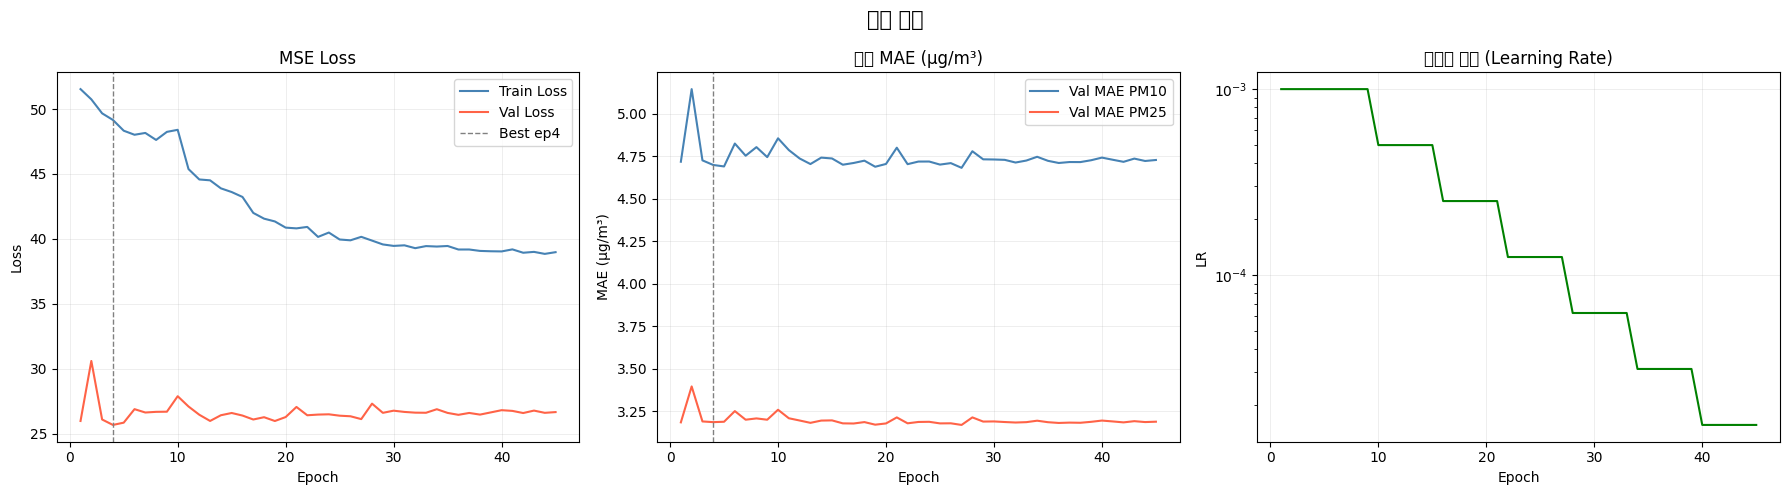

학습 곡선 저장 완료


In [51]:
# ── 학습 곡선 (Loss & MAE) ─────────────────────────────────────

epochs_list  = [h["epoch"]         for h in history]
train_losses = [h["train_loss"]    for h in history]
val_losses   = [h["val_loss"]      for h in history]
val_mae_pm10 = [h["val_mae_pm10"]  for h in history]
val_mae_pm25 = [h["val_mae_pm25"]  for h in history]
lrs          = [h["lr"]            for h in history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("학습 결과", fontsize=15)

# ① Loss 곡선
axes[0].plot(epochs_list, train_losses, label="Train Loss", color="steelblue")
axes[0].plot(epochs_list, val_losses,   label="Val Loss",   color="tomato")
axes[0].axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Best ep{best_epoch}")
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ② Val MAE 곡선
axes[1].plot(epochs_list, val_mae_pm10, label="Val MAE PM10", color="steelblue")
axes[1].plot(epochs_list, val_mae_pm25, label="Val MAE PM25", color="tomato")
axes[1].axvline(best_epoch, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("검증 MAE (μg/m³)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (μg/m³)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ③ 학습률 변화
axes[2].plot(epochs_list, lrs, color="green")
axes[2].set_title("학습률 변화 (Learning Rate)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale("log")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "training_curves.png"), dpi=150)
plt.show()
print("학습 곡선 저장 완료")

/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3938675505.py:33: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_l

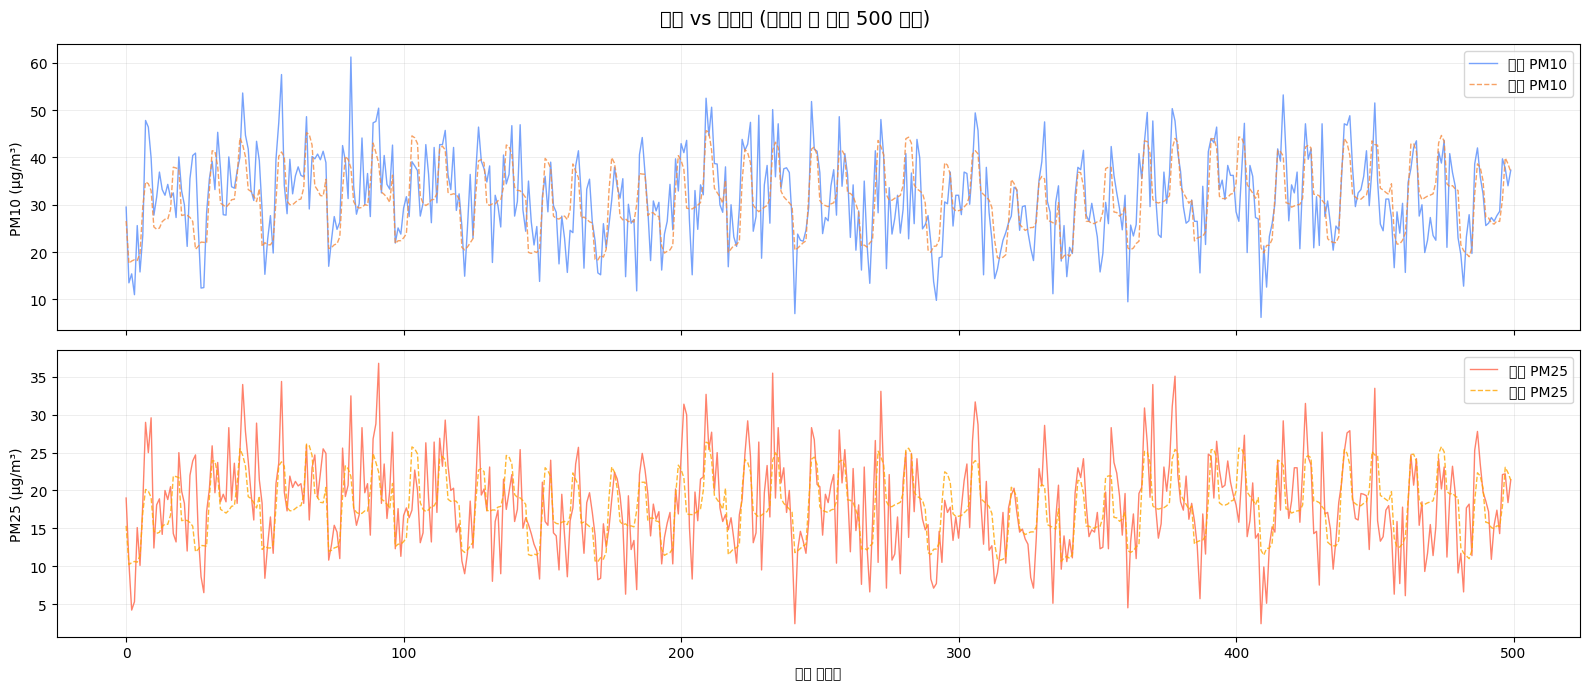

In [52]:
# ── 예측 vs 실제값 시각화 ─────────────────────────────────────

# 테스트 셋 전체 예측
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        p = model(X_b.to(DEVICE))
        all_preds.append(p.cpu().numpy())
        all_targets.append(y_b.numpy())

preds_np   = np.concatenate(all_preds)
targets_np = np.concatenate(all_targets)

# ① 시계열 비교 — 처음 500개 샘플
N = 500
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle("예측 vs 실제값 (테스트 셋 처음 500 샘플)", fontsize=14)

axes[0].plot(targets_np[:N, 0], label="실제 PM10", alpha=0.8, linewidth=1)
axes[0].plot(preds_np[:N, 0],   label="예측 PM10", alpha=0.8, linewidth=1, linestyle="--")
axes[0].set_ylabel("PM10 (μg/m³)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(targets_np[:N, 1], label="실제 PM25", alpha=0.8, linewidth=1, color="tomato")
axes[1].plot(preds_np[:N, 1],   label="예측 PM25", alpha=0.8, linewidth=1, linestyle="--", color="orange")
axes[1].set_ylabel("PM25 (μg/m³)")
axes[1].set_xlabel("샘플 인덱스")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "predictions_timeseries.png"), dpi=150)
plt.show()

/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1845/3688648533.py:26: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight

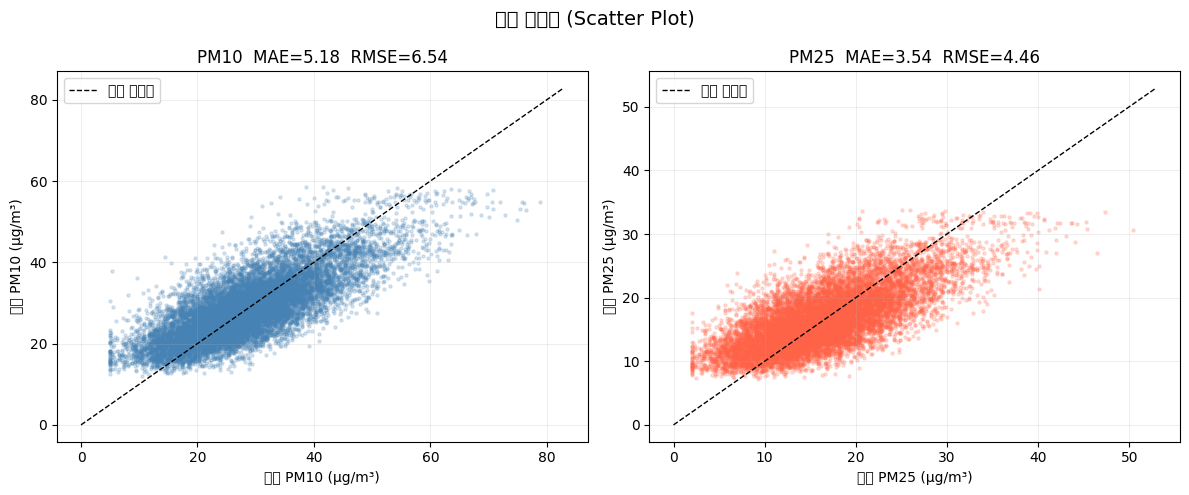

In [53]:
# ② 산점도 (Scatter Plot) — 예측 정확도 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("예측 정확도 (Scatter Plot)", fontsize=14)

for ax, idx, name, color in [
    (axes[0], 0, "PM10", "steelblue"),
    (axes[1], 1, "PM25", "tomato"),
]:
    t, p = targets_np[:, idx], preds_np[:, idx]
    ax.scatter(t, p, alpha=0.2, s=5, color=color)

    # 완벽 예측선 (y = x)
    lim = max(t.max(), p.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", linewidth=1, label="완벽 예측선")

    mae  = float(np.abs(t - p).mean())
    rmse = float(np.sqrt(((t - p) ** 2).mean()))

    ax.set_xlabel(f"실제 {name} (μg/m³)")
    ax.set_ylabel(f"예측 {name} (μg/m³)")
    ax.set_title(f"{name}  MAE={mae:.2f}  RMSE={rmse:.2f}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "scatter_plot.png"), dpi=150)
plt.show()

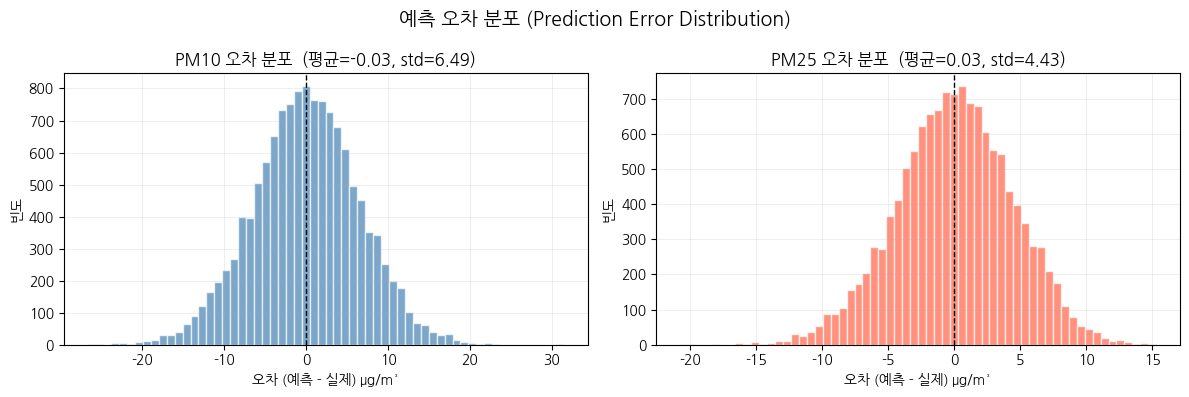

In [27]:
# ③ 오차 분포 히스토그램

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("예측 오차 분포 (Prediction Error Distribution)", fontsize=14)

for ax, idx, name, color in [
    (axes[0], 0, "PM10", "steelblue"),
    (axes[1], 1, "PM25", "tomato"),
]:
    errors = preds_np[:, idx] - targets_np[:, idx]
    ax.hist(errors, bins=60, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel(f"오차 (예측 - 실제) μg/m³")
    ax.set_ylabel("빈도")
    ax.set_title(f"{name} 오차 분포  (평균={errors.mean():.2f}, std={errors.std():.2f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "error_distribution.png"), dpi=150)
plt.show()

---
## 12. 모델 파일 다운로드

In [ ]:
import zipfile

# model_output 폴더 전체를 zip으로 압축 후 다운로드
ZIP_PATH = "air_quality_model_output.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(CONFIG["save_dir"]):
        fpath = os.path.join(CONFIG["save_dir"], fname)
        zf.write(fpath, arcname=fname)
        print(f"  압축: {fname}")

print(f"\n📦 {ZIP_PATH} 생성 완료")
print("다운로드 시작...")

files.download(ZIP_PATH)

---
## 📋 다운로드된 파일 설명

| 파일 | 설명 |
|---|---|
| `best_model.pt` | 최적 LSTM 모델 가중치 (PyTorch) |
| `scaler.pkl` | 입력 데이터 정규화 파라미터 (추론 시 필수) |
| `model_config.json` | 모델 구조 및 성능 기록 |
| `history.json` | epoch별 학습 곡선 데이터 |
| `training_curves.png` | 학습/검증 Loss & MAE 그래프 |
| `predictions_timeseries.png` | 예측 vs 실제 시계열 그래프 |
| `scatter_plot.png` | 예측 정확도 산점도 |
| `error_distribution.png` | 오차 분포 히스토그램 |

### 추론 예시 코드

```python
import torch, pickle, json, numpy as np

# 설정 로드
with open("model_config.json") as f:
    cfg = json.load(f)

# scaler 로드
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# 모델 로드
model = AirQualityLSTM(
    input_size=cfg["input_size"],
    hidden_size=cfg["hidden_size"],
    num_layers=cfg["num_layers"],
    dropout=cfg["dropout"],
)
model.load_state_dict(torch.load("best_model.pt", map_location="cpu"))
model.eval()

# 입력: 최근 24시간 데이터 (24 × 16 numpy array)
raw_input = np.array(...)      # shape: (24, 16)
scaled    = scaler.transform(raw_input)
tensor    = torch.tensor(scaled, dtype=torch.float32).unsqueeze(0)  # (1, 24, 16)

with torch.no_grad():
    pred = model(tensor)       # (1, 2)

pm10_pred, pm25_pred = pred[0].tolist()
print(f"PM10 예측: {pm10_pred:.1f} μg/m³")
print(f"PM25 예측: {pm25_pred:.1f} μg/m³")
```